In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importamos la base de datos

In [107]:
base = pd.read_csv('datos\\penguins.csv')
base

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


### vemos la cantidad total de registros

In [108]:
total_observaciones = len(base)
total_observaciones

344

### vemos que variables contiene la base

In [109]:
base.columns.to_frame(name='Nombres columnas')

,Nombres columnas
species,species
island,island
bill_length_mm,bill_length_mm
bill_depth_mm,bill_depth_mm
flipper_length_mm,flipper_length_mm
body_mass_g,body_mass_g
sex,sex
year,year


### Vemos las cantidad de nulos que hay por cada variable

In [110]:
cantidad_nulos = base.isnull().sum().reset_index()
cantidad_nulos.columns = ['columna', 'cantidad de valores nulos']
cantidad_nulos

,columna,cantidad de valores nulos
0,species,0
1,island,0
2,bill_length_mm,2
3,bill_depth_mm,2
4,flipper_length_mm,2
5,body_mass_g,2
6,sex,11
7,year,0


### Filtramos la base y nos quedamos sólo con las columnas requeridas

In [111]:
base = base[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
base

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,55.8,19.8,207.0,4000.0
340,43.5,18.1,202.0,3400.0
341,49.6,18.2,193.0,3775.0
342,50.8,19.0,210.0,4100.0


### quitamos los valores nulos de las variables

In [112]:
base.dropna(inplace=True)
base

C:\Users\109149\AppData\Local\Temp\ipykernel_26400\1408571916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base.dropna(inplace=True)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
339,55.8,19.8,207.0,4000.0
340,43.5,18.1,202.0,3400.0
341,49.6,18.2,193.0,3775.0
342,50.8,19.0,210.0,4100.0


### verificamos que ya no existan nulos

In [113]:
cantidad_nulos = base.isnull().sum().reset_index()
cantidad_nulos.columns = ['columna', 'cantidad de valores nulos']
cantidad_nulos

,columna,cantidad de valores nulos
0,bill_length_mm,0
1,bill_depth_mm,0
2,flipper_length_mm,0
3,body_mass_g,0


### volvemos a observar la cantidad de observaciones completas

In [114]:
total_observaciones = len(base)
total_observaciones

342

## Punto 1

In [115]:
X_1 = 'bill_length_mm'
X_2 = 'bill_depth_mm'
X_3 = 'flipper_length_mm'
X_4 = 'body_mass_g'

# de manera 'manual'
X_1_mean = base[X_1].sum()/total_observaciones
X_2_mean = base[X_2].sum()/total_observaciones
X_3_mean = base[X_3].sum()/total_observaciones
X_4_mean = base[X_4].sum()/total_observaciones

X_1_var = ((base[X_1]-X_1_mean)**2).sum()/(total_observaciones-1)
X_2_var = ((base[X_2]-X_2_mean)**2).sum()/(total_observaciones-1)
X_3_var = ((base[X_3]-X_3_mean)**2).sum()/(total_observaciones-1)
X_4_var = ((base[X_4]-X_4_mean)**2).sum()/(total_observaciones-1)

X_1_std = np.sqrt(X_1_var)
X_2_std = np.sqrt(X_2_var)
X_3_std = np.sqrt(X_3_var)
X_4_std = np.sqrt(X_4_var)


In [116]:
resultados = pd.DataFrame({'Variable': [X_1,X_2,X_3,X_4],
                            'Media': base.mean(),
                            'Varianza': base.var(),
                            'Desv. estándar': base.std()}).reset_index(drop=True)
resultados

,Variable,Media,Varianza,Desv. estándar
0,bill_length_mm,43.921930,29.807054,5.459584
1,bill_depth_mm,17.151170,3.899808,1.974793
2,flipper_length_mm,200.915205,197.731792,14.061714
3,body_mass_g,4201.754386,643131.077327,801.954536


### Punto 1.1

La media de la masa corporal representa en gramos el valor esperado de que un pinguino elegio al azar sea de ese peso, que en este caso en sde 4,201.6g, o es decir, 4.2kg

La media del largo de la aleta, indica la longitud promedio que tiene de aketa un pinguino.

Tanto la media de la longitus y promedio del pico, representan las dimensiones que promedio que tiene un pinguino

Es decir, todas conjuntas representan las medidas típicas que tiene un pinguno, sin embargo, puede que el pinguino que se describe con esas cualidades pueda no existir.

### Punto 1.2

La variable que representa mayor variabilidad podría ser la de 'body_mass_g' debido a que su varianza es muchisimo mas mayor que la propia media en comparación de las otras variables.

### Punto 1.3

No es correcto poderlas llegar a comprar, ya que, por ejemplo la variable 'body_mass_g' se mide en  g, mientras que las otra variables se miden en mm, por lo que no tiene sentido comparación, además la escala, es diferente, por ejemplo la 'profundiada de aleta', y 'masa corporal' debido a que uno tiene escala de alrededor de decenas (17.15)  y en la otra una escaala alrededor de miles (4201) por lo que están muy lejanas.

Por lo que para hacer una comparación se debería de utilizar alguna medida adimencional.

### Punto 1.4

La media muestral es una estimación de $E[X_j]$ debido a que como su nombre lo dice, a que es una medida que toma encuenta el dataset que estamos observando no a todos los pinguinos del mundo, sin embargo , para que se considere ya una media poblacional hay de tomnar las medidas de cada pinguino de la isla y así sacar su media, pero es muy complejo siempre conocer cada uno de todoas los registros.

## Punto 2

In [117]:
# de manera 'manual'
base_medias = base.mean()
diferencias = base - base_medias
sumatoria = diferencias.T.dot(diferencias)
matriz_covarianza = sumatoria/(total_observaciones-1)
matriz_covarianza

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,29.807054,-2.534234,50.375765,2605.591912
bill_depth_mm,-2.534234,3.899808,-16.212950,-747.370093
flipper_length_mm,50.375765,-16.212950,197.731792,9824.416062
body_mass_g,2605.591912,-747.370093,9824.416062,643131.077327


In [118]:
matriz_covarianza = base.cov()
matriz_covarianza

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,29.807054,-2.534234,50.375765,2605.591912
bill_depth_mm,-2.534234,3.899808,-16.212950,-747.370093
flipper_length_mm,50.375765,-16.212950,197.731792,9824.416062
body_mass_g,2605.591912,-747.370093,9824.416062,643131.077327


Text(0, 0.5, 'bill_length_mm')

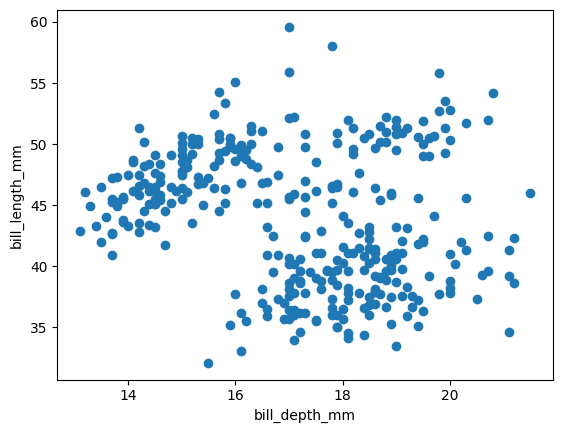

In [119]:
plt.scatter(base[X_2], base[X_1])
plt.xlabel(X_2)
plt.ylabel(X_1)


Text(0, 0.5, 'bill_depth_mm')

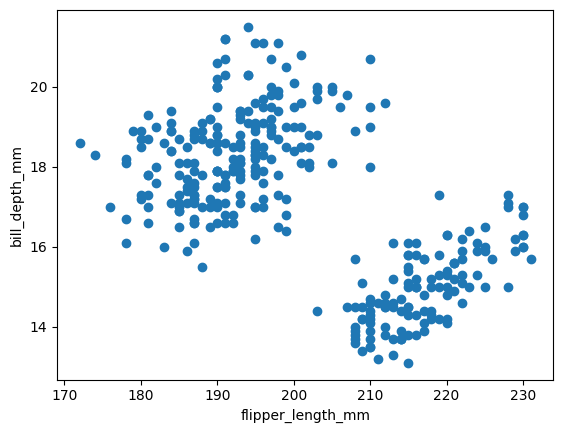

In [120]:
plt.scatter(base[X_3], base[X_2])
plt.xlabel(X_3)
plt.ylabel(X_2)

Realizamos los diagramas de dispersión de la variable 'bill_depth_mm' con '	bill_length_mm' ya tiene una covarianza de -5, además tambien se graficó el diagrama de dispersión de la variable 'flipper_length_mm' con 'bill_depth_mm' porque tiene una covarianza de -16, ambas se eligeron para graficar, ya que una covarianza cercana a 0 significa que no tienen una relación lineal, por lo que se opto para gráficas para ver su relación.

## Punto 3

In [121]:
Y = pd.DataFrame({X_3:base[X_3],
                X_4: base[X_4]})
Y.head()

,flipper_length_mm,body_mass_g
0,181.0,3750.0
1,186.0,3800.0
2,195.0,3250.0
4,193.0,3450.0
5,190.0,3650.0


### Punto 3a

Text(0, 0.5, 'body_mass_g')

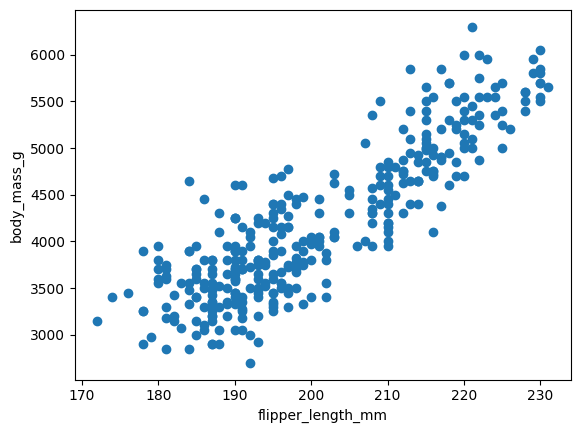

In [122]:
plt.scatter(Y[X_3], Y[X_4])
plt.xlabel(X_3)
plt.ylabel(X_4)

Text(0, 0.5, 'body_mass_g')

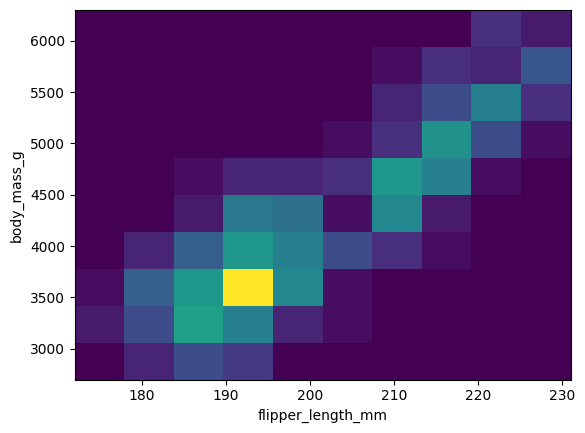

In [123]:
plt.hist2d(Y[X_3], Y[X_4])
plt.xlabel(X_3)
plt.ylabel(X_4)

Al analizar la distribución conjunta nos puede revelar si hay una depedencia entre ellas, es decir, sobre su correlación, como se puede ver tienen una correlación positiva, esto es que mientras una variable crece la otra también, además tambien podemos conocer los valores aproximados o zonas donde hay mayor concentración de registros, por ejemplo, podemos ver que hay una gran concentración de registros, cuando la longitud de la aleta mide alrededor de 192 mm y que la grasa corporal tenga un peso de alrededor de 3600g

### Punto 3b

In [124]:
vector_medias_y = Y.mean()
vector_medias_y

flipper_length_mm     200.915205
body_mass_g          4201.754386
dtype: float64

In [125]:
covarianza_Y = Y.cov()
covarianza_Y

,flipper_length_mm,body_mass_g
flipper_length_mm,197.731792,9824.416062
body_mass_g,9824.416062,643131.077327


Notamos que la media de la longitud de aleta es de 200mm y esta en un rango de $\sqrt{197}$, mientras que la grasa corporal tiene una media de 4201.74g y esta en un rango de $\sqrt{643131}$, además su covarianza entre estas dos variables es de 9824.4 lo que nos indica una correlación lineal.

### Punto 3c

In [126]:
def funcion_empirica(x_3, x_4):
    casos_favorables = (
        (Y[X_3] <= x_3) &
        (Y[X_4] <= x_4)
    ).sum()
    return float(casos_favorables/total_observaciones)

#### Punto 3c1

In [127]:
funcion_empirica(200,4000)

0.4649122807017544

#### Punto 3c2

In [128]:
interseccion = Y[(Y[X_3] <= 200) &(Y[X_4] <= 4000)]
probabilidad = len(interseccion)/total_observaciones
probabilidad

0.4649122807017544

Matemáticamente no hay diferencia entre una y otra porque ambas dieron los mismos resultados, ya que ambas funcionan de la misma manera, cuentan los casos que cumplen ambas condiciones al mismo tiempo y los dividen entre el total de casos disponibles

#### Punto 3c3

In [129]:
marginal_X3 = funcion_empirica(200,max(Y[X_4]))
marginal_X3

0.5672514619883041

In [130]:
marginal_X4 = funcion_empirica(max(Y[X_3]),4000)
marginal_X4

0.49707602339181284

In [131]:
marginal_X4*marginal_X3

0.28196710098833827

Notamos que la función empirica bivariada es menor a sus marginales, ya que los marginales al tomar más casos posibles tendremos mayor cantidad de casos favorables, por otra parte al realizar la multiplicación de las marginales nos damos cuenta que el resultado difiere a la probabilidad que nos da función empirica bivariada, esto nos demuestra que el masa corporal y la longitud de la aleta no son variables independientes, ya que si lo fueran ambos resultados darian exactamente el mismo.

#### Punto 3cd

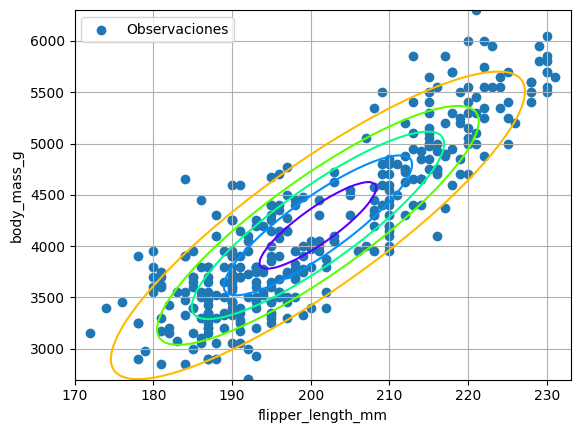

In [132]:
from scipy.stats import multivariate_normal

x = Y[X_3]
y = Y[X_4]
mu = vector_medias_y
cov_matrix = covarianza_Y

x_rango = np.linspace(x.min() - 2, x.max() + 2, 100)
y_rango = np.linspace(y.min() - 2, y.max() + 2, 100)
X_mesh, Y_mesh = np.meshgrid(x_rango, y_rango)

posiciones = np.dstack((X_mesh, Y_mesh))

modelo_n2 = multivariate_normal(mean=mu, cov=cov_matrix)
Z = modelo_n2.pdf(posiciones)

plt.scatter(x, y, label='Observaciones')
curvas = plt.contour(X_mesh, Y_mesh, Z, levels=6, cmap='gist_rainbow')

plt.xlabel(X_3)
plt.ylabel(X_4)
plt.legend()
plt.grid()
